# Clustering DBSCAN
Segmentation client avec DBSCAN

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

data = pd.read_csv("../data/marketing_campaign_cleaned.csv")
df = data.copy()

# Features comportementales (sans les catégorielles)
features = ['Income', 'Recency', 'TotalMnt', 'TotalPurchases', 'TotalChildren']
X = df[features]

print("Shape:", X.shape)
print(X.describe())

Shape: (2213, 5)
             Income       Recency      TotalMnt  TotalPurchases  TotalChildren
count  2.213000e+03  2.213000e+03  2.213000e+03    2.213000e+03   2.213000e+03
mean  -1.380630e-16  1.083634e-16  4.173997e-17    9.190821e-17   2.247537e-17
std    1.000226e+00  1.000226e+00  1.000226e+00    1.000226e+00   1.000226e+00
min   -2.006831e+00 -1.693930e+00 -9.993286e-01   -1.940485e+00  -1.263775e+00
25%   -6.726694e-01 -8.648923e-01 -8.931848e-01   -8.974211e-01  -1.263775e+00
50%   -3.450254e-02 -1.311176e-03 -3.491974e-01    1.525946e-02   7.181914e-02
75%    6.500931e-01  8.622700e-01  7.304848e-01    7.975571e-01   7.181914e-02
max    2.440219e+01  1.725851e+00  3.180086e+00    3.796365e+00   2.743008e+00


## Étape 1 : Trouver le bon epsilon (eps) avec la courbe k-distance

DBSCAN a 2 paramètres clés :
- **eps** : rayon de voisinage (à trouver via la courbe k-distance)
- **min_samples** : nb min de points pour former un cluster (règle : 2 × nb_features)

min_samples recommandé : 10


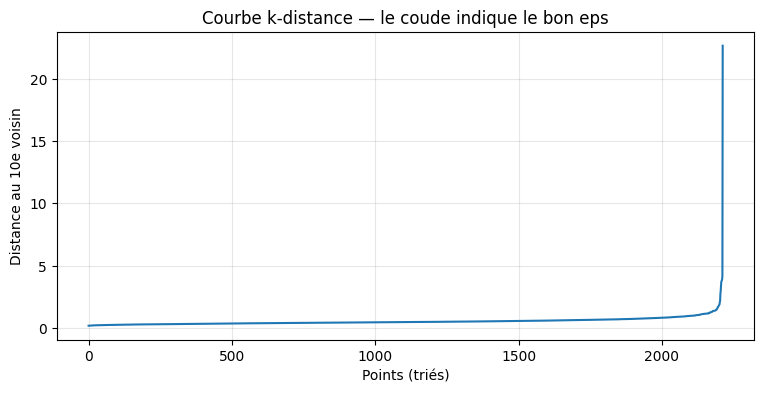


Valeurs de référence :
  Médiane des distances : 0.467
  75e percentile       : 0.608
  90e percentile       : 0.802


In [2]:
# Règle standard : min_samples = 2 * nb_features
min_samples = 2 * len(features)
print(f"min_samples recommandé : {min_samples}")

# Courbe k-distance pour trouver eps optimal
# Le "coude" de cette courbe indique le bon eps
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X)
distances, _ = nbrs.kneighbors(X)
distances = np.sort(distances[:, -1])  # distance au k-ième voisin

plt.figure(figsize=(9, 4))
plt.plot(distances)
plt.xlabel('Points (triés)')
plt.ylabel(f'Distance au {min_samples}e voisin')
plt.title('Courbe k-distance — le coude indique le bon eps')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nValeurs de référence :")
print(f"  Médiane des distances : {np.median(distances):.3f}")
print(f"  75e percentile       : {np.percentile(distances, 75):.3f}")
print(f"  90e percentile       : {np.percentile(distances, 90):.3f}")

## Étape 2 : Tester plusieurs valeurs d'eps et choisir la meilleure

In [3]:
# Tester une grille d'eps autour du coude
p75 = np.percentile(distances, 75)
p90 = np.percentile(distances, 90)
eps_values = np.linspace(p75 * 0.5, p90 * 1.5, 20)

results = []
for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    pct_noise = n_noise / len(labels) * 100
    
    # Silhouette seulement si au moins 2 clusters et peu de bruit
    score = None
    if n_clusters >= 2 and pct_noise < 30:
        # Exclure les points bruit pour le calcul
        mask = labels != -1
        if len(set(labels[mask])) >= 2:
            score = silhouette_score(X[mask], labels[mask])
    
    results.append({
        'eps': round(eps, 3),
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'pct_noise': round(pct_noise, 1),
        'silhouette': round(score, 4) if score else None
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

  eps  n_clusters  n_noise  pct_noise  silhouette
0.304           7     1657       74.9         NaN
0.352          17     1357       61.3         NaN
0.399          14     1055       47.7         NaN
0.446          10      768       34.7         NaN
0.493           8      566       25.6      0.0578
0.541           8      411       18.6      0.0231
0.588           5      302       13.6      0.1090
0.635           5      236       10.7      0.1126
0.682           5      165        7.5      0.1481
0.730           5      128        5.8      0.1481
0.777           4       99        4.5      0.1190
0.824           5       73        3.3      0.0983
0.872           5       58        2.6      0.1000
0.919           5       45        2.0      0.1006
0.966           4       40        1.8      0.1231
1.013           4       33        1.5      0.1226
1.061           4       31        1.4      0.1235
1.108           4       28        1.3      0.1235
1.155           4       28        1.3      0.1235


## Étape 3 : Sélectionner le meilleur eps (score silhouette max, bruit < 20%)

In [4]:
# Filtrer : au moins 2 clusters, bruit < 20%, silhouette disponible
valid = results_df[
    (results_df['n_clusters'] >= 2) &
    (results_df['pct_noise'] < 20) &
    (results_df['silhouette'].notna())
]

if valid.empty:
    # Assouplir le critère bruit
    valid = results_df[
        (results_df['n_clusters'] >= 2) &
        (results_df['silhouette'].notna())
    ]

best = valid.loc[valid['silhouette'].idxmax()]
best_eps = best['eps']

print(f"Meilleur eps : {best_eps}")
print(f"  Nb clusters  : {best['n_clusters']}")
print(f"  Bruit        : {best['pct_noise']}%")
print(f"  Silhouette   : {best['silhouette']}")

Meilleur eps : 0.682
  Nb clusters  : 5.0
  Bruit        : 7.5%
  Silhouette   : 0.1481


## Étape 4 : Clustering final

In [5]:
# Clustering final avec le meilleur eps
db_final = DBSCAN(eps=best_eps, min_samples=min_samples)
df["Cluster"] = db_final.fit_predict(X)

n_clusters = len(set(df["Cluster"])) - (1 if -1 in df["Cluster"].values else 0)
n_noise = (df["Cluster"] == -1).sum()

# Silhouette sans les points bruit
mask = df["Cluster"] != -1
score = silhouette_score(X[mask], df["Cluster"][mask])

print(f"Résultats DBSCAN final :")
print(f"  Nb clusters    : {n_clusters}")
print(f"  Points bruit   : {n_noise} ({n_noise/len(df)*100:.1f}%)")
print(f"  Silhouette     : {score:.4f}")
print(f"\nDistribution :")
print(df["Cluster"].value_counts().sort_index())
# -1 = points bruit (outliers)

Résultats DBSCAN final :
  Nb clusters    : 5
  Points bruit   : 166 (7.5%)
  Silhouette     : 0.1480

Distribution :
Cluster
-1     166
 0     368
 1     450
 2    1083
 3     136
 4      10
Name: count, dtype: int64


## Étape 5 : Profil des clusters

In [6]:
# Profil moyen (cluster -1 = bruit/outliers)
profil = df.groupby("Cluster")[features].mean().round(3)
profil.index = [f'Bruit (outliers)' if i == -1 else f'Cluster {i}' for i in profil.index]
print(profil)

                  Income  Recency  TotalMnt  TotalPurchases  TotalChildren
Bruit (outliers)   0.628    0.020     0.498           0.586          0.707
Cluster 0         -0.397    0.023    -0.719          -0.526          1.407
Cluster 1          0.942    0.016     1.302           0.690         -1.264
Cluster 2         -0.235   -0.009    -0.272          -0.080          0.072
Cluster 3         -0.901   -0.140    -0.738          -0.852         -1.264
Cluster 4         -0.521    1.014    -0.923          -1.093          2.743


## Étape 6 : Visualisation PCA

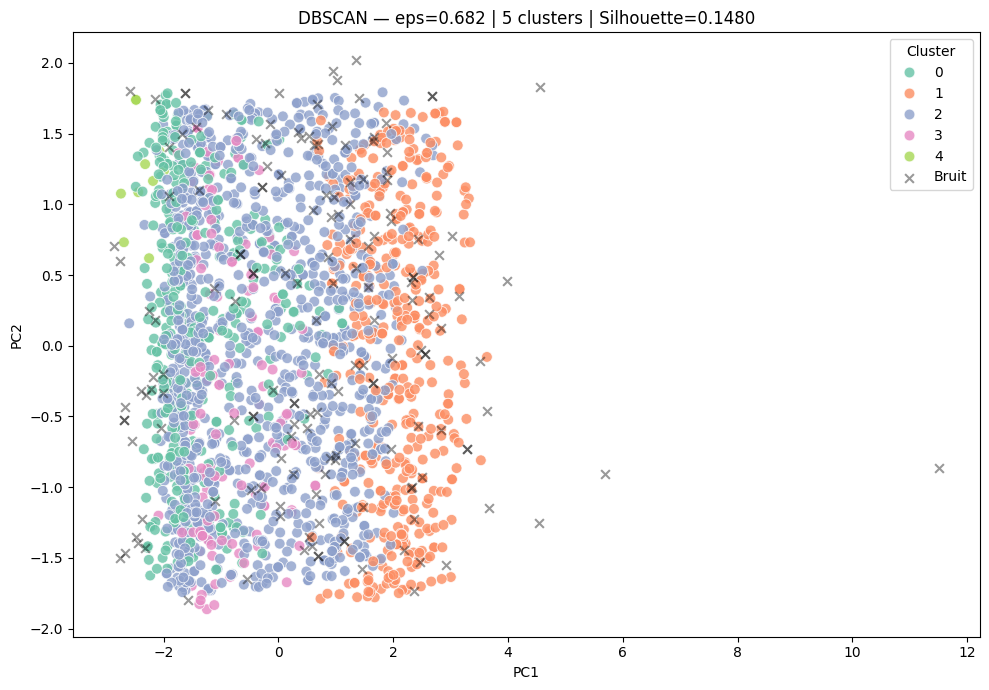

Variance expliquée PC1+PC2 : 71.4%


In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = df["Cluster"].values

# Séparer clusters normaux et bruit
normal = pca_df[pca_df["Cluster"] != -1]
bruit  = pca_df[pca_df["Cluster"] == -1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x="PC1", y="PC2", hue="Cluster",
    data=normal, palette="Set2", alpha=0.8, s=60
)
plt.scatter(
    bruit["PC1"], bruit["PC2"],
    c='black', marker='x', s=40, alpha=0.4, label='Bruit'
)
plt.legend(title='Cluster')
plt.title(f"DBSCAN — eps={best_eps} | {n_clusters} clusters | Silhouette={score:.4f}")
plt.tight_layout()
plt.show()

print(f"Variance expliquée PC1+PC2 : {pca.explained_variance_ratio_.sum()*100:.1f}%")

## Étape 7 : Scatter Income vs TotalMnt (comme dans ton notebook original)

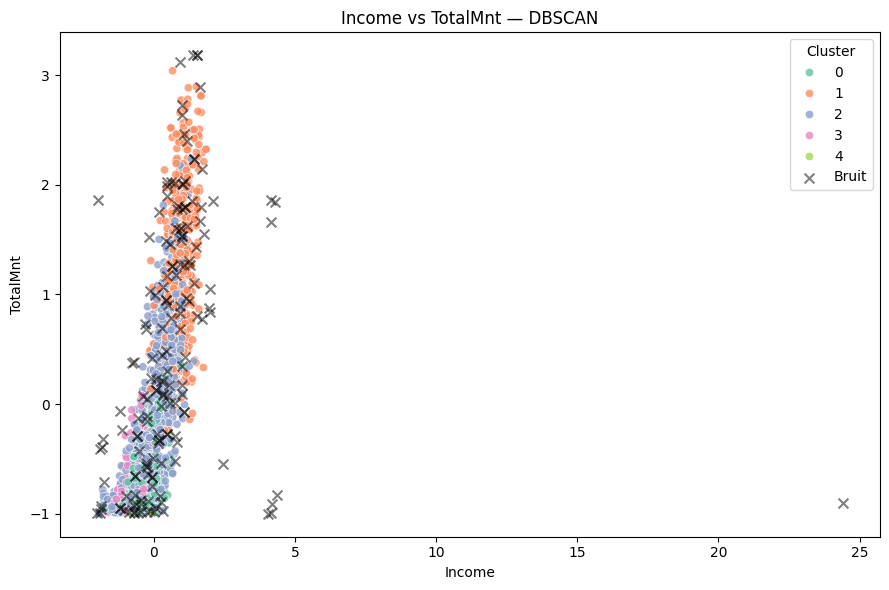

In [8]:
plt.figure(figsize=(9, 6))

# Clusters normaux
normal_df = df[df["Cluster"] != -1]
sns.scatterplot(
    x=normal_df["Income"], y=normal_df["TotalMnt"],
    hue=normal_df["Cluster"], palette="Set2", alpha=0.8
)

# Outliers en noir
bruit_df = df[df["Cluster"] == -1]
plt.scatter(
    bruit_df["Income"], bruit_df["TotalMnt"],
    c='black', marker='x', s=50, alpha=0.5, label='Bruit'
)

plt.legend(title='Cluster')
plt.title('Income vs TotalMnt — DBSCAN')
plt.tight_layout()
plt.show()